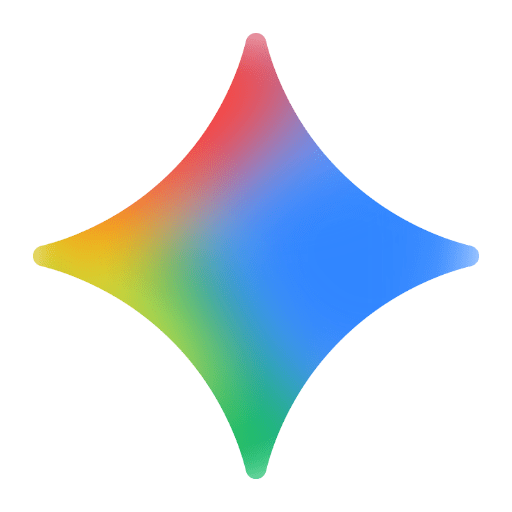

# Chapter 16: Embodied and Physical World Agents

> From **30 Agents Every AI Engineer Must Build** by Imran Ahmad (Packt Publishing, 2026)  
> **Book pages 457–491** | [GitHub Repository](https://github.com/PacktPublishing/30-Agents-Every-AI-Engineer-Must-Build/chapter16)

---

## Introduction

> *"The world is its own best model."*  
> — Rodney Brooks, co-founder of iRobot and former director of MIT CSAIL

In 1966, researchers at Stanford set a wheeled robot named **Shakey** loose in a corridor and watched it reason about pushing blocks. The lesson was immediate: intelligence that acts in the physical world earns every decision against gravity, friction, and consequence. NASA's Sojourner rover crossed Martian terrain three decades later under the same constraint. Today, autonomous drones navigate storms and construction sites with no human at the controls.

This qualitative difference creates what the chapter calls the **physicality constraint** — decomposed into three concrete properties:

| Property | Description |
|---|---|
| **Irreversibility** | Physical actions cannot be rolled back once executed; planning must account for worst-case outcomes before committing |
| **Latency** | Mechanical actuators, communication links, and sensor pipelines introduce delays that accumulate in real-time control loops |
| **Energy limits** | Onboard power is finite and non-replenishable mid-mission; every action carries an energy cost that bounds the feasible plan space |

The chapter addresses this constraint through a fundamental **depth–breadth divide**:

- **Depth Problem (Embodied Intelligence Agent):** Controlling a single physical system with millisecond precision and hard safety guarantees — a layered control hierarchy from LLM-based strategic reasoning down to 1–10 kHz servo-level motor control.
- **Breadth Problem (Domain-Transforming Integration Agent):** Coordinating heterogeneous infrastructure systems with complex cross-domain dependencies — modeled as a typed knowledge graph with weighted influence propagation.

These two architectures are brought together in a **drone mission case study** set in Ottawa's winter conditions, where real-time flight control operates within a **Unified Constraint Envelope** derived from weather, energy, regulatory, and mission constraints. The central principle: **conservative constraint fusion** — autonomous systems must satisfy *all* constraints simultaneously, with safety enforced as a precondition for action rather than an afterthought.

### Notebook Structure

| Section | Listings | Book Pages |
|---|---|---|
| Setup & Environment Detection | — | p. 458 |
| Architectural Foundations | — | pp. 458–462 |
| Control Hierarchy & World Model | Pseudocode | pp. 462–468 |
| Embodied Agent Implementation | 16.1, 16.2, 16.3 | pp. 468–472 |
| Domain-Transforming Integration Agent | 16.4, 16.5 | pp. 476–479 |
| Ottawa Drone Case Study | 16.6, 16.7 | pp. 480–489 |
| Failure Scenario Demonstrations | — | pp. 489–490 |


### Figure 16.1 — The Depth–Breadth Divide (p. 459)

```
┌─────────────────────────────────────────────────────────────────────────┐
│                    AUTONOMOUS PHYSICAL SYSTEM                           │
│                                                                         │
│   ┌───────────────────────┐         ┌───────────────────────────────┐   │
│   │   DEPTH PROBLEM       │         │   BREADTH PROBLEM             │   │
│   │   (Embodied Agent)    │         │   (Integration Agent)         │   │
│   │                       │         │                               │   │
│   │  ┌─────────────────┐  │         │  ┌─────────────────────────┐  │   │
│   │  │ Task Planning   │  │         │  │ Weather ←→ Energy       │  │   │
│   │  │ (0.1-1 Hz)     │  │         │  │     ↕          ↕        │  │   │
│   │  ├─────────────────┤  │         │  │ Airspace ←→ Transport   │  │   │
│   │  │ Motion Planning │  │         │  │     ↕          ↕        │  │   │
│   │  │ (1-10 Hz)      │  │         │  │ Parks ←──→ Mission      │  │   │
│   │  ├─────────────────┤  │         │  └─────────────────────────┘  │   │
│   │  │ Trajectory Ctrl │  │         │  Cross-domain knowledge graph │   │
│   │  │ (50-200 Hz)    │  │         │  with influence propagation    │   │
│   │  ├─────────────────┤  │         │                               │   │
│   │  │ Servo Control   │  │         │                               │   │
│   │  │ (1-10 kHz)     │  │         │                               │   │
│   │  └─────────────────┘  │         └───────────────────────────────┘   │
│   └───────────────────────┘                                             │
│                                                                         │
│               ┌─────────────────────────────────┐                       │
│               │  UNIFIED CONSTRAINT ENVELOPE     │                       │
│               │  Conservative Constraint Fusion  │                       │
│               │  ALL domains must be GREEN       │                       │
│               └─────────────────────────────────┘                       │
└─────────────────────────────────────────────────────────────────────────┘
```


In [1]:
import os
os.environ["LLM_PROVIDER"] = "google"

# Cell 2: Environment Setup — Imports, .env Loading, SIMULATION_MODE Detection
# Ref: §Technical requirements (p. 458)
# Author: Imran Ahmad
#
# Cascading fallback: .env → getpass → Simulation Mode
# The getpass prompt is skipped in non-interactive environments (e.g. nbconvert)
# to prevent blocking during automated validation.

import os
import sys
import json
from pathlib import Path

# --- Install check (idempotent) ---
# Uncomment the following line if running in a fresh environment:
# !pip install -q langchain==0.2.16 langchain-google-genai langgraph==0.1.4 google-generativeai pydantic==2.8.2 python-dotenv==1.0.1

# --- Load .env if present ---
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass  # python-dotenv not installed; rely on environment variables

# --- API key resolution with getpass fallback ---
api_key = os.environ.get("GOOGLE_API_KEY", "")

if not api_key or api_key == "your-google-api-key-here":
    # Only prompt if running interactively (not under nbconvert --execute)
    if sys.stdin.isatty():
        try:
            import getpass
            api_key = getpass.getpass(
                "Enter your Google API key (or press Enter for Simulation Mode): "
            )
            if api_key:
                os.environ["GOOGLE_API_KEY"] = api_key
        except (EOFError, OSError):
            api_key = ""

# --- Determine mode ---
SIMULATION_MODE = not (api_key and "your-key" not in api_key and "your_key" not in api_key)

print(f"SIMULATION_MODE = {SIMULATION_MODE}")

SIMULATION_MODE = False


In [2]:
# Cell 3: Resilience Layer Imports
# Ref: Visual Logging Schema specification
# Author: Imran Ahmad
#
# ColorLogger provides ANSI-colored output:
#   Blue=INFO, Green=SUCCESS, Red=ERROR, Yellow=SIMULATION/WARNING
# fail_gracefully wraps functions with retry + exponential backoff + fallback.

from resilience import ColorLogger, fail_gracefully, logger

# Verify the logger is operational
if SIMULATION_MODE:
    logger.simulation(
        "Resilience layer loaded — ColorLogger + @fail_gracefully ready.",
        section_ref="§Visual Logging Schema",
    )
else:
    logger.info(
        "Resilience layer loaded — ColorLogger + @fail_gracefully ready.",
        section_ref="§Visual Logging Schema",
    )

[INFO] [§Visual Logging Schema] Resilience layer loaded — ColorLogger + @fail_gracefully ready.


In [3]:
# Cell 4: LLM Initialization via Factory
# Ref: §Technical requirements (p. 458)
# Author: Imran Ahmad
#
# get_llm() returns MockChatOpenAI (simulation) or ChatGoogleGenerativeAI (live).
# The returned object is a BaseChatModel compatible with
# langgraph.prebuilt.create_react_agent.

from mock_layer import get_llm

llm = get_llm(SIMULATION_MODE)

# Confirm type for traceability
logger.info(
    f"LLM initialized: {type(llm).__name__} "
    f"(_llm_type={llm._llm_type})",
    section_ref="§Technical requirements",
)

[ERROR] [§Technical requirements] Failed to initialize ChatOpenAI: 1 validation error for ChatOpenAI
__root__
  Client.__init__() got an unexpected keyword argument 'proxies' (type=type_error). Falling back to Simulation Mode.
[INFO] [§Technical requirements] LLM initialized: MockChatOpenAI (_llm_type=mock-chat-openai)


## Architectural Foundations: The Depth–Breadth Divide

**§Architectural foundations (pp. 458–462) — Figure 16.1**

Physical-world agents confront two distinct problems that no single architectural pattern can serve simultaneously:

**The Depth Problem** — controlling a single physical system with millisecond precision, hard safety guarantees, and deterministic feedback. A warehouse robot picking items from shelves must fuse noisy sensor data, plan collision-free trajectories, execute within millisecond control loops, and halt immediately if a human enters its workspace. The reasoning is *deep* (multiple abstraction levels from strategic goals to motor currents) but *narrow* (confined to one robot in one physical domain).

**The Breadth Problem** — coordinating multiple infrastructure systems whose states influence one another through measurable but complex transfer functions. A power outage disables traffic signals, which increases congestion, which delays ambulance response times. The reasoning is *broad* (spanning heterogeneous systems with different physics, time scales, and regulatory constraints) but comparatively *slow*.

These two problems demand fundamentally different architectural responses:

| Property | Depth (Embodied Intelligence) | Breadth (Domain-Transforming Integration) |
|----------|------------------------------|------------------------------------------|
| Scope | Single physical domain | Multiple coupled domains |
| Time scale | Milliseconds to seconds | Minutes to policy cycles |
| Control | Tight, real-time, deterministic | Loose, deliberative, tolerant of uncertainty |
| Architecture | Multi-rate control hierarchy | Typed knowledge graph + influence propagation |

The solution: an **Asymmetric Control Loop** separating a high-latency reasoning layer (LLM-based) from a low-latency deterministic controller. The agent provides the "why" and "what"; the controller manages the "how" within physical safety bounds.

## Control Hierarchy as Time Scale Decomposition

**§Control hierarchy as time scale decomposition (pp. 462–466) — Table 16.1, Figure 16.2**

The embodied agent distributes responsibility across layers running at different frequencies. Higher layers reason symbolically over seconds. Lower layers regulate torque and current at kilohertz rates.

| Level | Abstraction | Frequency | Algorithm Class |
|-------|------------|-----------|----------------|
| Task Planning | Symbolic goals | 0.1–1 Hz | PDDL planners, LLM reasoning |
| Motion Planning | Collision-free paths | 1–10 Hz | RRT*, PRM, optimization methods |
| Trajectory Control | Time-parameterized path | 50–200 Hz | PID, model predictive control |
| Servo Control | Motor currents | 1–10 kHz | Current and torque loops |

This hierarchy enforces stability. The servo layer rejects disturbances within milliseconds. Trajectory control maintains smooth tracking. Motion planners compute feasible paths. Task planners reason over discrete objectives. Each layer exposes a constrained interface to the one above it.

The following cell implements simplified skeletons for the lower three layers (no LLM involvement). The task-planning layer is implemented later as a LangChain agent (Listing 16.2).

In [4]:
# Cell 7: Lower-Layer Control Skeletons (Pseudocode)
# Ref: §Control hierarchy as time scale decomposition (pp. 466–467)
# Author: Imran Ahmad
#
# These are architectural scaffolds illustrating the lower three layers
# from Table 16.1. Production implementations depend on hardware-specific
# drivers and real-time operating system primitives.

import math


# --- Motion Planning layer (1-10 Hz, RRT*/PRM) ---
def plan_motion_trajectory(goal_pose, world_model_state, obstacles):
    """Compute a collision-free path from current pose to goal.

    Frequency: 1-10 Hz. Algorithm class: RRT*, PRM.
    Ref: Table 16.1 row 2 (p. 463)

    In production, this calls a sampling-based planner (RRT* or PRM)
    over the robot's configuration space. Here we return a simplified
    linear interpolation as a pedagogical scaffold.
    """
    current_pose = world_model_state.get("pose", {"x": 0.0, "y": 0.0})
    # Simplified: straight-line path with 5 waypoints
    path = []
    for t in [i / 4.0 for i in range(5)]:
        wp = {
            "x": current_pose["x"] + t * (goal_pose["x"] - current_pose["x"]),
            "y": current_pose["y"] + t * (goal_pose["y"] - current_pose["y"]),
        }
        path.append(wp)
    return path  # List of waypoints for trajectory layer


# --- Trajectory Control layer (50-200 Hz, PID/MPC) ---
def compute_trajectory_setpoints(path, dt=0.005):
    """Time-parameterize the path into setpoints at the control frequency.

    Frequency: 50-200 Hz. Algorithm class: PID, model predictive control.
    Ref: Table 16.1 row 3 (p. 463)

    Yields torque commands consumed by the servo layer.
    In production, this runs a PID or MPC controller against encoder feedback.
    """
    kp = 1.0  # Proportional gain (simplified)
    for waypoint in path:
        # Simulated encoder reading
        current = {"x": waypoint["x"] * 0.98, "y": waypoint["y"] * 0.98}
        error_x = waypoint["x"] - current["x"]
        error_y = waypoint["y"] - current["y"]
        torque = {
            "tx": kp * error_x / max(dt, 1e-6),
            "ty": kp * error_y / max(dt, 1e-6),
        }
        yield torque  # Consumed by servo layer


# --- Servo Control layer (1-10 kHz, current loops) ---
def servo_control_loop(torque_setpoint, dt=0.0001):
    """Regulate motor current to achieve commanded torque.

    Frequency: 1-10 kHz. Rejects electrical and mechanical disturbances.
    Ref: Table 16.1 row 4 (p. 463)

    Returns the PWM signal that would be written to the motor driver.
    In production, this runs on a real-time microcontroller.
    """
    # Simplified current-to-torque conversion
    motor_constant = 0.05  # Nm/A
    target_current = {
        "ix": torque_setpoint.get("tx", 0) / motor_constant,
        "iy": torque_setpoint.get("ty", 0) / motor_constant,
    }
    # Simulated current reading (with noise)
    measured_current = {
        "ix": target_current["ix"] * 0.95,
        "iy": target_current["iy"] * 0.95,
    }
    pwm = {
        "px": (target_current["ix"] - measured_current["ix"]) / max(dt, 1e-6),
        "py": (target_current["iy"] - measured_current["iy"]) / max(dt, 1e-6),
    }
    return pwm


# --- Demo: run the three-layer pipeline ---
logger.info("Lower-layer control skeleton demo", section_ref="§Control hierarchy (pp. 466–467)")

demo_state = {"pose": {"x": 0.0, "y": 0.0}}
demo_goal = {"x": 5.0, "y": 3.0}
demo_obstacles = []  # No obstacles in scaffold

path = plan_motion_trajectory(demo_goal, demo_state, demo_obstacles)
logger.info(f"Motion Planning: {len(path)} waypoints generated")

setpoints = list(compute_trajectory_setpoints(path))
logger.info(f"Trajectory Control: {len(setpoints)} torque setpoints at dt=5ms")

pwm = servo_control_loop(setpoints[-1])
logger.info(f"Servo Control: PWM signal = px={pwm['px']:.1f}, py={pwm['py']:.1f}")
logger.success("Three-layer control pipeline executed", section_ref="§Control hierarchy")

[INFO] [§Control hierarchy (pp. 466–467)] Lower-layer control skeleton demo
[INFO] Motion Planning: 5 waypoints generated
[INFO] Trajectory Control: 5 torque setpoints at dt=5ms
[INFO] Servo Control: PWM signal = px=200000.0, py=120000.0
[SUCCESS] [§Control hierarchy] Three-layer control pipeline executed


## World Model as a Physics Engine

**§World model as a physics engine (pp. 466–467)**

The world model maintains a structured representation of the environment — not raw camera frames or lidar point clouds, but **inferred object states**: estimated poses, occupied/free regions, and spatial relationships. The planning layers query these inferred states directly; sensor data is never exposed.

Two types of reasoning are centralized in the world model:

**Spatial reasoning** — estimating object poses from noisy depth returns, computing bounding volumes for collision detection, and tracking free-space corridors as obstacles move.

**Physics reasoning** — evaluating whether an action is physically feasible. For example, stability holds only if the projection of a package's center of mass remains within its support polygon:

$$\sum F_i = 0, \quad \sum \tau_i = 0$$

The invariant: **no action is executed without being evaluated against a coherent internal representation of the world.** The world model exposes queryable methods that the planning layers call directly — grasp difficulty estimates, collision status along paths, placement feasibility checks.

The next cell implements Listing 16.1: the interface stubs that define this world model contract.

In [5]:
# Cell 9: Listing 16.1 — Common Setup: Shared Interface Stubs
# Ref: §Implementation: LangChain embodied agent patterns (pp. 468–469)
# Author: Imran Ahmad
#
# These stubs define the interface contracts that all subsequent listings
# reference. In Simulation Mode, they return chapter-accurate mock data.
# In production, they would be replaced with hardware-specific implementations
# (ROS2 action servers, MAVLink telemetry, sensor drivers).

from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional
from resilience import fail_gracefully


# --- Embodied Intelligence Agent stubs (Listings 16.2-16.3) ---

class WorldModel:
    """Maintains belief state b(s) over robot and environment.
    Ref: §World model as a physics engine (pp. 466–467)"""

    def __init__(self):
        self._state = {
            "pose": {"x": 0.0, "y": 0.0, "z": 0.0},
            "package_A": {
                "pose": {"x": 2.3, "y": 1.1, "z": 0.8},
                "weight_kg": 4.5,
                "grasp_difficulty": 0.3,  # 0=easy, 1=hard
            },
            "shelf_B": {
                "pose": {"x": 5.0, "y": 3.0, "z": 1.2},
                "free_space": True,
            },
            "obstacles": [],
            "humans_in_perimeter": False,
        }

    def query(self, query: str) -> dict:
        """Query the world model for object states, collision status,
        or grasp difficulty estimates."""
        q = query.lower()
        if "package" in q and "location" in q or "grasp" in q:
            return {
                "package_A_pose": self._state["package_A"]["pose"],
                "grasp_difficulty": self._state["package_A"]["grasp_difficulty"],
                "weight_kg": self._state["package_A"]["weight_kg"],
                "path_to_shelf_B": "collision_free",
                "shelf_B_free": self._state["shelf_B"]["free_space"],
            }
        if "collision" in q or "path" in q:
            return {"collision_free": True, "obstacles_detected": 0}
        return self._state

    def get_current_state(self) -> dict:
        """Return full belief state b(s)."""
        return dict(self._state)

    def update(self, observations: dict) -> None:
        """Update belief state with fresh sensor observations."""
        self._state.update(observations)


class ControlInterface:
    """Dispatches validated commands to the deterministic controller (50-200 Hz).
    Ref: §Multi-rate perception-action integration (pp. 467–468)"""

    @dataclass
    class ExecutionResult:
        success: bool = True
        actuator_ok: bool = True
        fault_code: str = ""
        observations: dict = field(default_factory=dict)

    def execute(self, target: str = "", action: str = "",
                timeout: float = 5.0, **kwargs) -> "ControlInterface.ExecutionResult":
        """Execute a validated command. Returns result with observations."""
        return self.ExecutionResult(
            success=True,
            actuator_ok=True,
            observations={"action_completed": action, "target": target},
        )


@dataclass
class ValidationResult:
    is_safe: bool = True
    reason: str = ""
    constraints: str = ""


class SafetyMonitor:
    """Validates actions against A_safe(s) before execution.
    Ref: §Multi-rate perception-action integration (pp. 467–468)

    Safety is not an emergent property of correct planning.
    It is an explicit restriction on the set of actions the system may execute."""

    def validate(self, action, target_or_state) -> ValidationResult:
        """Validate an action against the admissible action set A_safe(s)."""
        return ValidationResult(
            is_safe=True,
            reason="All constraints satisfied",
            constraints="workspace_bounds, force_limits, velocity_caps",
        )

    def halt(self, reason: str = "") -> None:
        """Emergency halt — unconditional override."""
        logger.error(f"HALT: {reason}", section_ref="§Safety enforcement")


def extract_actions(plan) -> list:
    """Parse proposed actions from agent plan output.
    In simulation, returns a single validated action."""
    return [{"action": "pick_and_place", "target": "package_A", "destination": "shelf_B"}]


# --- Stubs for Domain-Transforming Integration Agent (Listings 16.4) ---

class _EnergyAPI:
    def get_substations(self, region: str) -> list:
        """Ref: Listing 16.4 (p. 476) — query_energy_grid tool."""
        return [{"id": "Substation-7", "capacity_mw": 45, "load_mw": 38,
                 "status": "operational", "region": region}]


class _TrafficAPI:
    def get_network(self, region: str) -> list:
        """Ref: Listing 16.4 (pp. 477–478) — query_traffic_network tool."""
        return [{"id": "TrafficController-12", "intersections": 14,
                 "throughput_pct": 100, "signal_status": "normal", "region": region}]


# --- Global instances ---
world_model = WorldModel()
control_interface = ControlInterface()
safety_monitor = SafetyMonitor()
energy_api = _EnergyAPI()
traffic_api = _TrafficAPI()

# Re-use MockGraph from src as the knowledge graph backend
from mock_layer import MockGraph
knowledge_graph = MockGraph()

logger.success(
    "Listing 16.1 stubs initialized: WorldModel, ControlInterface, "
    "SafetyMonitor, EnergyAPI, TrafficAPI, KnowledgeGraph",
    section_ref="§Implementation: LangChain patterns (pp. 468-469)",
)

[SUCCESS] [§Implementation: LangChain patterns (pp. 468-469)] Listing 16.1 stubs initialized: WorldModel, ControlInterface, SafetyMonitor, EnergyAPI, TrafficAPI, KnowledgeGraph


In [6]:
# Cell 10: Listing 16.2 — Embodied Agent with Four-Responsibility Tool Decomposition
# Ref: §Implementation: LangChain embodied agent patterns (pp. 469–470)
# Author: Imran Ahmad
#
# Each tool maps to exactly one responsibility:
#   query_world_model        → Model Maintenance
#   dispatch_motion_command  → Real-Time Control
#   check_safety_constraints → Safety Enforcement
#   LLM (via create_react_agent) → Strategic Reasoning
#
# The LLM cannot bypass the safety layer. The tool architecture enforces
# the same trust boundary described in the chapter: the reasoning layer
# proposes, but the deterministic controller disposes.

from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent


# --- Model Maintenance: query the world model ---
@tool
def query_world_model(query: str) -> dict:
    """Query the robot's world model for object poses,
    collision status, or grasp difficulty estimates.
    Ref: Listing 16.2 (p. 469) — Model Maintenance responsibility."""
    return _query_world_model_impl(query)

@fail_gracefully(fallback_value={"error": "world model unavailable"},
                 section_ref="§World model (pp. 466–467)")
def _query_world_model_impl(query: str) -> dict:
    return world_model.query(query)


# --- Real-Time Control: dispatch validated commands ---
@tool
def dispatch_motion_command(target: str, action: str) -> dict:
    """Submit a motion command through the control interface.
    Safety validation occurs before dispatch.
    Ref: Listing 16.2 (p. 470) — Real-Time Control responsibility."""
    return _dispatch_motion_command_impl(target, action)

@fail_gracefully(fallback_value={"error": "command dispatch failed"},
                 section_ref="§Multi-rate perception-action (pp. 467–468)")
def _dispatch_motion_command_impl(target: str, action: str) -> dict:
    result = control_interface.execute(target=target, action=action)
    return {"success": result.success, "target": target, "action": action}


# --- Safety Enforcement: validate before execution ---
@tool
def check_safety_constraints(action: str, target: str) -> dict:
    """Validate an action against the admissible action set A_safe(s).
    Checks workspace bounds, force limits, velocity caps.
    Ref: Listing 16.2 (p. 470) — Safety Enforcement responsibility."""
    return _check_safety_constraints_impl(action, target)

@fail_gracefully(fallback_value={"is_safe": False, "reason": "safety check failed"},
                 section_ref="§Safety enforcement (pp. 467-468)")
def _check_safety_constraints_impl(action: str, target: str) -> dict:
    result = safety_monitor.validate(action, target)
    return {"is_safe": result.is_safe, "reason": result.reason,
            "constraints": result.constraints}


# --- Strategic Reasoning: LLM agent with tool access ---
embodied_tools = [
    query_world_model,
    dispatch_motion_command,
    check_safety_constraints,
]

embodied_agent = create_react_agent(llm, embodied_tools)

logger.success(
    f"Listing 16.2: Embodied agent created with {len(embodied_tools)} tools "
    f"using {type(llm).__name__}",
    section_ref="§Implementation: LangChain patterns (pp. 469-470)",
)

[SIMULATION] [§Simulation Mode] MockChatOpenAI.bind_tools: ['query_world_model', 'dispatch_motion_command', 'check_safety_constraints']
[SUCCESS] [§Implementation: LangChain patterns (pp. 469-470)] Listing 16.2: Embodied agent created with 3 tools using MockChatOpenAI


### Figure 16.3 — Layered Command Interface (p. 466)

The safety enforcement layer sits between the control interface and the actuators, *not* alongside the reasoning layer. This architectural choice means the LLM reasoning layer cannot bypass safety constraints even if it proposes an unsafe action.

```
  ┌──────────────────┐
  │  LLM Reasoning   │  Strategic decisions (0.1-1 Hz)
  │  Layer (Agent)    │
  └────────┬─────────┘
           │ tool calls
           ▼
  ┌──────────────────┐
  │  Tool-Mediated   │  query_world_model()
  │  Interface       │  dispatch_motion_command()
  │                  │  check_safety_constraints()
  └────────┬─────────┘
           │
           ▼
  ┌──────────────────┐
  │  SAFETY MONITOR  │  Validates against A_safe(s)
  │  ███████████████ │  ← HARD GATE: rejects unsafe actions
  └────────┬─────────┘
           │ validated commands only
           ▼
  ┌──────────────────┐
  │  Control         │  Trajectory + Servo layers
  │  Interface       │  (50-200 Hz, 1-10 kHz)
  └────────┬─────────┘
           │
           ▼
      ⚙️ ACTUATORS
```


In [7]:
# Cell 11: Listing 16.3 — Safety-Constrained Action Execution Loop
# Ref: §Multi-rate perception-action integration (pp. 470–472)
# Author: Imran Ahmad
#
# Before any action reaches the control interface, the safety monitor
# validates it against A_safe(s) evaluated at the current world state.
# If validation fails, the rejection reason and active constraints are
# fed back to the LLM for replanning.

from langchain_core.messages import HumanMessage


def execute_with_safety(agent, task: str, wm, sm):
    """Execute an embodied task with pre-execution safety validation
    and continuous monitoring.

    Ref: Listing 16.3 (pp. 470-472)

    Protocol:
        1. Agent reasons about the task and proposes actions
        2. Extract proposed actions from agent output
        3. Validate each action against A_safe(s)
        4. Execute validated actions; reject and replan if unsafe
    """
    logger.info(f"Executing task: {task}", section_ref="§Listing 16.3")

    # Step 1: Agent reasons about the task and proposes actions
    plan = agent.invoke({"messages": [HumanMessage(content=task)]})

    # Step 2: Extract proposed actions from agent output
    actions = extract_actions(plan)
    logger.info(f"Proposed {len(actions)} action(s)", section_ref="§Listing 16.3")

    results = []
    for i, action in enumerate(actions):
        # Step 3: Validate each action against A_safe(s)
        state = wm.get_current_state()
        validation = sm.validate(action, state)

        if not validation.is_safe:
            # Rejected: replan with constraint feedback
            logger.error(
                f"Action {i+1} rejected: {validation.reason}",
                section_ref="§Safety enforcement",
            )
            plan = agent.invoke({"messages": [
                HumanMessage(
                    content=(
                        f"Action rejected: {validation.reason}. "
                        f"Replan within: {validation.constraints}"
                    )
                )
            ]})
            continue

        logger.constraint("A_safe(s)", True,
                          f"Action {i+1} validated",
                          section_ref="§Listing 16.3")

        # Step 4: Execute validated action with timeout
        try:
            result = control_interface.execute(
                target=action.get("target", ""),
                action=action.get("action", ""),
                timeout=5.0,
            )
            if not result.actuator_ok:
                sm.halt(reason=result.fault_code)
                break
            wm.update(result.observations)
            results.append({"action": action, "success": True})
            logger.success(
                f"Action {i+1} executed: {action.get('action', '')}",
                section_ref="§Listing 16.3",
            )
        except TimeoutError:
            sm.halt(reason="execution_timeout")
            logger.error("Execution timeout — halted", section_ref="§Listing 16.3")
            break

    return {"plan_output": plan, "execution_results": results}


logger.success(
    "Listing 16.3: execute_with_safety() defined",
    section_ref="§Multi-rate perception-action (pp. 470-472)",
)

[SUCCESS] [§Multi-rate perception-action (pp. 470-472)] Listing 16.3: execute_with_safety() defined


In [8]:
# Cell 12: Demo — Warehouse Robot Scenario (Embodied Agent)
# Ref: §Implementation: LangChain embodied agent patterns (pp. 467–472)
# Author: Imran Ahmad
#
# Scenario: "Move package A to shelf B."
# This single instruction conceals a cascade of computational problems:
# locate package A, plan collision-free path, compute grasp strategy,
# navigate to shelf B, and guarantee safety throughout.

logger.info("=" * 60)
logger.info(
    "DEMO: Warehouse Robot — 'Move package A to shelf B'",
    section_ref="§Implementation (pp. 467-472)",
)
logger.info("=" * 60)

# Method 1: Direct agent invocation (Listing 16.2 pattern)
logger.info("\n--- Method 1: Direct Agent Invocation (Listing 16.2) ---")
result = embodied_agent.invoke({
    "messages": [
        HumanMessage(
            content=(
                "Move package A to shelf B in the warehouse. "
                "First query the world model for package A location and grasp "
                "difficulty, then check safety constraints, then dispatch the "
                "motion command."
            )
        )
    ]
})

# Print agent message trace
logger.info("Agent message trace:")
for i, msg in enumerate(result["messages"]):
    msg_type = type(msg).__name__
    tool_calls = getattr(msg, "tool_calls", None)
    if tool_calls:
        names = [tc["name"] for tc in tool_calls]
        logger.info(f"  [{i}] {msg_type} → tool_calls={names}")
    elif hasattr(msg, "content") and msg.content:
        preview = msg.content[:80]
        logger.info(f"  [{i}] {msg_type}: {preview}...")

# Final agent response
final_msg = result["messages"][-1].content
logger.success(f"\nAgent response: {final_msg[:120]}...")

# Method 2: Safety-constrained execution loop (Listing 16.3 pattern)
logger.info("\n--- Method 2: Safety-Constrained Execution (Listing 16.3) ---")
exec_result = execute_with_safety(
    agent=embodied_agent,
    task="Move package A to shelf B.",
    wm=world_model,
    sm=safety_monitor,
)
logger.info(f"Execution results: {len(exec_result['execution_results'])} action(s) completed")
logger.success("Warehouse robot demo complete", section_ref="§Implementation")

[INFO] ============================================================
[INFO] [§Implementation (pp. 467-472)] DEMO: Warehouse Robot — 'Move package A to shelf B'
[INFO] ============================================================
[INFO] 
--- Method 1: Direct Agent Invocation (Listing 16.2) ---
[INFO] Agent message trace:
[INFO]   [0] HumanMessage: Move package A to shelf B in the warehouse. First query the world model for pack...
[INFO]   [1] AIMessage → tool_calls=['query_world_model']
[INFO]   [2] ToolMessage: {"package_A_pose": {"x": 2.3, "y": 1.1, "z": 0.8}, "grasp_difficulty": 0.3, "wei...
[INFO]   [3] AIMessage → tool_calls=['check_safety_constraints']
[INFO]   [4] ToolMessage: {"is_safe": true, "reason": "All constraints satisfied", "constraints": "workspa...
[INFO]   [5] AIMessage → tool_calls=['dispatch_motion_command']
[INFO]   [6] ToolMessage: {"success": true, "target": "shelf_B", "action": "place_package_A"}...
[INFO]   [7] AIMessage: Mission complete. Package A has been pick

> **📦 Info Box: When Robots Meet the Real World — The Kiva Systems Revolution** *(p. 472)*
>
> In 2012, Amazon paid $775 million for Kiva Systems, a startup that had built squat orange robots to shuttle shelving units across warehouse floors. Skeptics questioned the price tag. The robots were slow, limited to flat surfaces, and could only operate in carefully mapped environments.
>
> But Kiva's founders understood something the robotics establishment had overlooked: **in logistics, reliability at scale matters more than capability at the edge.** A robot that successfully completes 99.8% of simple fetch tasks across a fleet of 800 units moves more product than a dozen sophisticated arms that fail unpredictably.
>
> By 2024, Amazon had deployed over **750,000 robotic units** across its fulfillment network, rebranded as Amazon Robotics. The architectural lesson endures: **fleet-level orchestration, conservative safety margins, and graceful degradation** when individual robots fail.


## The Domain-Transforming Integration Agent

**§The Domain-Transforming Integration agent (pp. 472–476) — Figure 16.1 (breadth side)**

The Embodied Intelligence agent coordinates perception, planning, and actuation within a *single* physical domain. The Domain-Transforming Integration agent operates at a different scale: it coordinates **multiple partially coupled dynamical systems**, each with its own state variables, control laws, time scales, and regulatory constraints.

### Coupled Heterogeneous Dynamical Systems

Each domain *i* can be modeled as a dynamical system with internal evolution and cross-domain perturbations:

$$\frac{dx_i}{dt} = f_i(x_i, u_i) + \sum_j g_{ij}(x_j)$$

Where $x_i$ is the state vector, $u_i$ represents exogenous inputs, $f_i$ encodes internal dynamics, and $g_{ij}$ captures coupling from domain *j* to domain *i*.

### Structural Topology: The Domain Knowledge Graph

The discrete structure of cross-domain influence is captured as a typed heterogeneous graph $G = (V, E)$:

- **V**: typed entities across domains (substations, traffic controllers, intersections)
- **E**: typed, weighted, and directional relations (powers, governs, affects)

### Influence Propagation

A weighted breadth-first traversal with multiplicative attenuation provides first-order impact estimates. Starting from a disrupted entity, influence propagates along outgoing edges, scaled by edge weight at each hop. Propagation stops when influence falls below a threshold — this prevents spurious amplification across long dependency chains.

The next cells implement these patterns as LangChain tools and a pure-Python BFS traversal.

> **⚠️ Info Box: Simulation vs. Prediction** *(p. 475)*
>
> Simulation outputs are **exploratory**. They inform policy and contingency planning. They do not guarantee predictive certainty. The influence propagation algorithm provides first-order impact estimates — useful for prioritizing responses, but not a substitute for domain-expert validation of cascade effects.


In [9]:
# Cell 14: Listing 16.4 — Cross-Domain Knowledge Graph Construction via Tool-Calling
# Ref: §LangChain integration agent patterns (pp. 476–478)
# Author: Imran Ahmad
#
# The graph formalism G = (V, E) maps onto a two-role tool set:
#   - Domain query tools populate V with typed entities
#   - register_cross_domain_edge populates E with weighted relations
#
# The LLM's role is semantic: given domain data from both sources, it
# identifies cross-domain dependencies and estimates coupling weights.

from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent


# --- Domain-specific data source tools ---

@tool
def query_energy_grid(region: str) -> list:
    """Query substations, capacity, and load for a region.
    Ref: Listing 16.4 (p. 476) — populates V with Energy-domain nodes."""
    return _query_energy_grid_impl(region)

@fail_gracefully(fallback_value=[], section_ref="§Listing 16.4")
def _query_energy_grid_impl(region: str) -> list:
    return energy_api.get_substations(region)


@tool
def query_traffic_network(region: str) -> list:
    """Query intersections, controllers, and throughput.
    Ref: Listing 16.4 (pp. 477–478) — populates V with Transportation-domain nodes."""
    return _query_traffic_network_impl(region)

@fail_gracefully(fallback_value=[], section_ref="§Listing 16.4")
def _query_traffic_network_impl(region: str) -> list:
    return traffic_api.get_network(region)


@tool
def register_cross_domain_edge(
    source_id: str, target_id: str,
    relation: str, weight: float,
) -> dict:
    """Register a typed, weighted edge between two entities in different domains.
    Ref: Listing 16.4 (pp. 477–478) — populates E in G = (V, E)."""
    return _register_edge_impl(source_id, target_id, relation, weight)

@fail_gracefully(fallback_value={"error": "edge registration failed"},
                 section_ref="§Structural topology (p. 474)")
def _register_edge_impl(source_id, target_id, relation, weight):
    return knowledge_graph.add_edge(source_id, target_id, relation, weight)


# --- Graph construction agent ---
graph_builder_tools = [
    query_energy_grid,
    query_traffic_network,
    register_cross_domain_edge,
]

graph_builder = create_react_agent(llm, graph_builder_tools)

logger.success(
    f"Listing 16.4: Graph builder agent created with {len(graph_builder_tools)} tools",
    section_ref="§LangChain integration patterns (pp. 476-478)",
)

[SIMULATION] [§Simulation Mode] MockChatOpenAI.bind_tools: ['query_energy_grid', 'query_traffic_network', 'register_cross_domain_edge']
[SUCCESS] [§LangChain integration patterns (pp. 476-478)] Listing 16.4: Graph builder agent created with 3 tools


In [10]:
# Cell 15: Listing 16.5 — Influence Propagation via Weighted Breadth-First Traversal
# Ref: §Influence propagation and impact estimation (pp. 478–479)
# Author: Imran Ahmad
#
# Pure Python — no LLM or mock needed. This is the implementation-level
# realization of the stability heuristic: the graph captures influence
# topology, but only propagation above the threshold is operationally
# meaningful.

from collections import deque


def propagate_influence(
    graph, source_id: str,
    initial_strength: float = 1.0,
    threshold: float = 0.1,
) -> dict:
    """Weighted BFS: propagate influence from a source entity through
    the cross-domain knowledge graph.

    Ref: Listing 16.5 (pp. 478-479)

    Returns {entity_id: (strength, [path])} for all reachable entities
    where propagated strength exceeds the threshold.

    The attenuation cutoff (threshold=0.1) prevents spurious amplification
    across long dependency chains — this is the stability heuristic from
    §Influence propagation (p. 479).

    Args:
        graph: Object with outgoing_edges(node_id) -> List[Edge]
        source_id: Starting entity for disruption
        initial_strength: Disruption magnitude at source (default 1.0)
        threshold: Minimum propagated strength to continue (default 0.1)

    Returns:
        Dict mapping entity_id -> (strength, path_list)
    """
    impacts = {source_id: (initial_strength, [source_id])}
    queue = deque([(source_id, initial_strength, [source_id])])

    while queue:
        node_id, strength, path = queue.popleft()

        for edge in graph.outgoing_edges(node_id):
            propagated = strength * edge.weight

            if propagated < threshold:
                continue  # Attenuation cutoff

            new_path = path + [edge.target_id]

            # Keep strongest path to each entity
            if (
                edge.target_id not in impacts
                or propagated > impacts[edge.target_id][0]
            ):
                impacts[edge.target_id] = (propagated, new_path)
                queue.append((edge.target_id, propagated, new_path))

    return impacts


logger.success(
    "Listing 16.5: propagate_influence() defined (pure Python, no mock needed)",
    section_ref="§Influence propagation (pp. 478-479)",
)

[SUCCESS] [§Influence propagation (pp. 478-479)] Listing 16.5: propagate_influence() defined (pure Python, no mock needed)


In [11]:
# Cell 16: Demo — Influence Propagation: Substation-7 Cascade
# Ref: §Influence propagation and impact estimation (pp. 478–479)
# Author: Imran Ahmad
#
# Scenario from the chapter (p. 474): "When a substation fails and grid
# load drops, traffic signals at 14 downstream intersections lose power,
# forcing them into default flashing-red mode. Signal-free intersections
# reduce throughput by approximately 60%."

from mock_layer import build_city_storm_graph

logger.info("=" * 60)
logger.info(
    "DEMO: Influence Propagation — Substation-7 Failure Cascade",
    section_ref="§Influence propagation (pp. 478-479)",
)
logger.info("=" * 60)

# Build the city/storm scenario graph from chapter narrative
city_graph = build_city_storm_graph()

# Propagate influence from Substation-7 (lightning strike disables it)
impacts = propagate_influence(
    graph=city_graph,
    source_id="Substation-7",
    initial_strength=1.0,
    threshold=0.1,
)

# Display results with color-coded severity
logger.info(f"\nImpact assessment: {len(impacts)} entities affected\n")

for entity_id, (strength, path) in sorted(
    impacts.items(), key=lambda x: -x[1][0]
):
    path_str = " → ".join(path)

    if strength >= 0.8:
        logger.error(
            f"  {entity_id}: strength={strength:.2f}  path=[{path_str}]",
            section_ref="CRITICAL",
        )
    elif strength >= 0.4:
        logger.warning(
            f"  {entity_id}: strength={strength:.2f}  path=[{path_str}]",
            section_ref="HIGH",
        )
    else:
        logger.info(
            f"  {entity_id}: strength={strength:.2f}  path=[{path_str}]",
        )

# Summary statistics
critical = sum(1 for _, (s, _) in impacts.items() if s >= 0.8)
high = sum(1 for _, (s, _) in impacts.items() if 0.4 <= s < 0.8)
moderate = sum(1 for _, (s, _) in impacts.items() if 0.1 <= s < 0.4)

logger.info(f"\nSummary: {critical} critical, {high} high, {moderate} moderate impact entities")
logger.success(
    "Influence propagation demo complete — cascade traced through "
    "Energy → Transportation → Emergency domains",
    section_ref="§Structural topology (p. 474)",
)

[INFO] ============================================================
[INFO] [§Influence propagation (pp. 478-479)] DEMO: Influence Propagation — Substation-7 Failure Cascade
[INFO] ============================================================
[INFO] 
Impact assessment: 17 entities affected

[ERROR] [CRITICAL]   Substation-7: strength=1.00  path=[Substation-7]
[ERROR] [CRITICAL]   TrafficController-12: strength=0.85  path=[Substation-7 → TrafficController-12]
[WARNING] [HIGH]   Intersection-1: strength=0.59  path=[Substation-7 → TrafficController-12 → Intersection-1]
[WARNING] [HIGH]   Intersection-2: strength=0.59  path=[Substation-7 → TrafficController-12 → Intersection-2]
[WARNING] [HIGH]   Intersection-3: strength=0.59  path=[Substation-7 → TrafficController-12 → Intersection-3]
[WARNING] [HIGH]   Intersection-4: strength=0.59  path=[Substation-7 → TrafficController-12 → Intersection-4]
[WARNING] [HIGH]   Intersection-5: strength=0.59  path=[Substation-7 → TrafficController-12 → Inter

## Case Study: Autonomous Drone Mission Planning in Ottawa's Winter Conditions

**§Case study (pp. 480–482) — Figures 16.4**

Ottawa in January delivers sub-zero temperatures, gusting northwesterly winds off the Ottawa River, and precipitation that alternates between freezing rain and driven snow. This environment stresses all five constraint domains simultaneously, making it a maximally demanding test of the joint architecture.

### Mission Scenario

An operator instructs an autonomous drone to conduct a photographic survey along a **6 km corridor** from **Centerpointe Technology Park** (Nepean) to the **Ottawa River waterfront**. The corridor crosses two regulatory zones:

1. **Controlled urban airspace** — Transport Canada, Canadian Aviation Regulations (CARs) Part IX
2. **National Capital Greenbelt** — Parks Canada overflight restrictions

### Unified Constraint Envelope

The drone may not arm until ALL five domains report GREEN:

| Domain | Constraint | Threshold | Source |
|--------|-----------|-----------|--------|
| **Weather** | Temperature | > −10°C (author-defined operational limit) | p. 481 |
| **Weather** | Wind speed | < 25 km/h at mission altitude | p. 481 |
| **Weather** | Precipitation | None active in corridor | p. 481 |
| **Battery** | Departure SoC | ≥ 30% | p. 481 |
| **Battery** | Waypoint minimum | ≥ 20% projected at any waypoint | p. 481 |
| **Battery** | Return reserve | ≥ 15% at return-to-home | p. 481 |
| **Airspace** | NOTAMs | No active TFR in corridor | p. 481 |
| **Parks** | Greenbelt authorization | On file with NCC | p. 481 |
| **Mission** | Route geometry | Structurally feasible | p. 481 |

**Conservative constraint fusion:** A single domain returning RED vetoes the entire envelope, regardless of how favorably the remaining domains report.

The next cells implement Listings 16.6 (Embodied drone agent) and 16.7 (cross-domain constraint assembler), then compose them into the full mission execution pipeline.

### Unified Constraint Envelope — Go/No-Go Decision Matrix (pp. 480–482)

The drone may not arm until the constraint assembler reports a fully **GREEN** envelope across all five domains:

```
          WEATHER          BATTERY          AIRSPACE          PARKS           MISSION
        ┌──────────┐    ┌──────────┐    ┌──────────┐    ┌──────────┐    ┌──────────┐
        │ Temp>-10°│    │ SoC≥30%  │    │ No active│    │ NCC auth │    │ Route    │
        │ Wind<25  │    │ WP≥20%   │    │  NOTAMs  │    │ on file  │    │ feasible │
        │ No precip│    │ RTH≥15%  │    │ in corr. │    │          │    │          │
        └────┬─────┘    └────┬─────┘    └────┬─────┘    └────┬─────┘    └────┬─────┘
             │               │               │               │               │
             └───────┬───────┴───────┬───────┴───────┬───────┘               │
                     │               │               │                       │
                     ▼               ▼               ▼                       │
              ┌─────────────────────────────────────────────────────────────┐│
              │      CONSERVATIVE CONSTRAINT FUSION (logical AND)           ││
              │  ALL domains GREEN  →  envelope_green = True  →  ARM MOTORS ││
              │  ANY domain RED     →  envelope_green = False →  HOLD/ABORT │◄┘
              │  ANY domain STALE   →  treated as RED until refreshed       │
              └─────────────────────────────────────────────────────────────┘
```


In [12]:
# Cell 18: Listing 16.6 — Embodied Drone Agent with Safety-Constrained Mission Execution
# Ref: §Implementation (pp. 482–485)
# Author: Imran Ahmad
#
# Maps the four-layer control hierarchy to the drone domain:
#   Task Planning (0.1-1 Hz)  → Mission Supervisor (LLM agent)
#   Motion Planning (1-10 Hz) → Flight Planner (waypoint computation)
#   Trajectory + Servo        → Autopilot firmware (independent of LLM)
#   Safety Enforcement        → Unified Constraint Envelope (A_safe(s))

from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent
from dataclasses import dataclass, field
import json


@dataclass
class DroneFlightState:
    """Current belief state b(s) over the drone's physical and
    environmental state.
    Ref: Listing 16.6 (p. 482) — POMDP formulation from §Embodied Intelligence."""
    position_lat: float = 0.0       # Current GPS latitude
    position_lon: float = 0.0       # Current GPS longitude
    altitude_m: float = 0.0         # Current altitude (metres AGL)
    battery_soc: float = 1.0        # State of Charge, 0.0-1.0
    wind_speed_kmh: float = 0.0     # Wind speed at mission altitude
    temperature_c: float = 0.0      # Ambient temperature
    precipitation_active: bool = False  # Any active precip in corridor
    constraint_envelope_green: bool = False  # Unified Constraint Envelope status


# --- Tool layer: maps to control hierarchy ---

@tool
def check_flight_safety(state_json: str) -> dict:
    """Safety enforcement layer: validate current state against the
    Unified Constraint Envelope (§Constraint formalization, p. 481).
    Maps to A_safe(s) from the Embodied Intelligence Agent section.
    Returns go/no-go with per-domain status."""
    return _check_flight_safety_impl(state_json)

@fail_gracefully(
    fallback_value={"envelope_green": False, "error": "safety check failed"},
    section_ref="§Constraint formalization (p. 481)",
)
def _check_flight_safety_impl(state_json: str) -> dict:
    s = json.loads(state_json)
    checks = {
        "temperature": s.get("temperature_c", -999) > -10.0,   # Author-defined limit (p. 481)
        "wind": s.get("wind_speed_kmh", 999) < 25.0,           # Mission-specific limit (p. 481)
        "precipitation": not s.get("precipitation_active", True),
        "battery_departure": s.get("battery_soc", 0) >= 0.30,  # SoC floor: 30% (p. 481)
    }
    envelope_green = all(checks.values())

    # Log each domain check
    for domain, met in checks.items():
        logger.constraint(domain, met, section_ref="§Constraint formalization")

    return {
        "envelope_green": envelope_green,
        "domain_status": checks,
        "safe_to_fly": envelope_green,
    }


@tool
def query_flight_state(drone_id: str) -> dict:
    """World-model query layer: retrieve current telemetry belief state
    b(s) from drone sensors and environmental APIs.
    Ref: Listing 16.6 (p. 483) — maps to task-planning layer."""
    return _query_flight_state_impl(drone_id)

@fail_gracefully(
    fallback_value={"error": "telemetry unavailable"},
    section_ref="§Listing 16.6 (p. 483)",
)
def _query_flight_state_impl(drone_id: str) -> dict:
    # Production: query live telemetry + weather API + battery management system
    # Simulation: chapter-accurate values from §Constraint formalization
    return {
        "position_lat": 45.3490,       # Centerpointe Technology Park, Nepean
        "position_lon": -75.7544,
        "altitude_m": 0.0,
        "battery_soc": 0.82,           # 82% — above 30% floor
        "wind_speed_kmh": 18.5,        # Below 25 km/h ceiling
        "temperature_c": -6.2,         # Above -10°C limit
        "precipitation_active": False,
        "constraint_envelope_green": False,  # Not yet evaluated
    }


@tool
def dispatch_waypoint_command(
    waypoint_lat: float, waypoint_lon: float,
    altitude_m: float, airspeed_kmh: float,
) -> dict:
    """Motion-planning interface: submit a validated waypoint command to
    the deterministic flight controller (50-200 Hz loop).
    This tool may only be called after check_flight_safety returns
    envelope_green=True.
    Ref: Listing 16.6 (pp. 483-484)"""
    return _dispatch_waypoint_impl(waypoint_lat, waypoint_lon, altitude_m, airspeed_kmh)

@fail_gracefully(
    fallback_value={"command_accepted": False, "error": "dispatch failed"},
    section_ref="§Listing 16.6 (pp. 483-484)",
)
def _dispatch_waypoint_impl(waypoint_lat, waypoint_lon, altitude_m, airspeed_kmh):
    # Production: serialize to MAVLink protocol and send to autopilot firmware
    logger.success(
        f"Waypoint dispatched: ({waypoint_lat:.4f}°N, {abs(waypoint_lon):.4f}°W) "
        f"at {altitude_m}m AGL, {airspeed_kmh} km/h",
        section_ref="§Motion planning layer",
    )
    return {
        "command_accepted": True,
        "waypoint": {
            "lat": waypoint_lat, "lon": waypoint_lon,
            "alt": altitude_m, "airspeed": airspeed_kmh,
        },
        "estimated_duration_s": 120,
    }


# --- Mission Supervisor agent (task-planning layer, 0.1-1 Hz) ---

mission_supervisor_tools = [
    check_flight_safety,
    query_flight_state,
    dispatch_waypoint_command,
]

mission_supervisor = create_react_agent(llm, mission_supervisor_tools)


def execute_mission(operator_instruction: str) -> str:
    """Entry point: translate operator intent into authorized flight actions.

    Ref: Listing 16.6 continued (pp. 484-485)

    Protocol:
        (1) call query_flight_state to retrieve current b(s)
        (2) call check_flight_safety with the state JSON
        (3) Only if envelope_green is True, call dispatch_waypoint_command
        (4) If envelope_green is False, report which domains failed and do not arm
    """
    result = mission_supervisor.invoke({
        "messages": [
            {
                "role": "user",
                "content": (
                    f"{operator_instruction}\n\n"
                    "Protocol: (1) call query_flight_state to retrieve current b(s). "
                    "(2) call check_flight_safety with the state JSON. "
                    "(3) Only if envelope_green is True, call dispatch_waypoint_command. "
                    "(4) If envelope_green is False, report which domains failed and do not arm."
                ),
            }
        ]
    })
    return result["messages"][-1].content


logger.success(
    f"Listing 16.6: Mission Supervisor created with {len(mission_supervisor_tools)} tools",
    section_ref="§Implementation (pp. 482-485)",
)

[SIMULATION] [§Simulation Mode] MockChatOpenAI.bind_tools: ['check_flight_safety', 'query_flight_state', 'dispatch_waypoint_command']
[SUCCESS] [§Implementation (pp. 482-485)] Listing 16.6: Mission Supervisor created with 3 tools


In [13]:
# Cell 19: Listing 16.7 — Cross-Domain Constraint Assembler with NOTAM Integration
# Ref: §Implementation (pp. 485–488)
# Author: Imran Ahmad
#
# Implements the Domain-Transforming Integration agent at the drone-mission
# scale. Each domain query tool corresponds to a typed node cluster in
# G = (V, E). Conservative constraint fusion: a single RED domain vetoes
# the entire envelope.

from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent


# --- Domain query tools (extend Listing 16.4 pattern) ---

@tool
def query_weather_constraints(corridor_id: str) -> dict:
    """Query real-time weather data for the specified flight corridor.
    Returns constraint-relevant fields: temperature, wind, precipitation.
    Ref: Listing 16.7 (pp. 485-486) — populates Weather node cluster."""
    return _query_weather_impl(corridor_id)

@fail_gracefully(
    fallback_value={"error": "weather API unavailable",
                    "temperature_constraint_met": False,
                    "wind_constraint_met": False,
                    "precip_constraint_met": False},
    section_ref="§Constraint formalization (p. 481)",
)
def _query_weather_impl(corridor_id: str) -> dict:
    # Production: query Environment Canada API or equivalent
    return {
        "temperature_c": -6.2,
        "wind_speed_kmh": 18.5,
        "precipitation_active": False,
        "temperature_constraint_met": True,   # > -10°C
        "wind_constraint_met": True,          # < 25 km/h
        "precip_constraint_met": True,
    }


@tool
def query_airspace_notams(corridor_id: str) -> dict:
    """Query Transport Canada NOTAM feed for active flight restrictions.
    NOTAM: Notice to Air Missions — standard Transport Canada format
    for real-time airspace restriction alerts issued under CARs Part IX.
    Ref: Listing 16.7 (pp. 486-487) — populates Airspace node cluster."""
    return _query_notams_impl(corridor_id)

@fail_gracefully(
    fallback_value={"airspace_constraint_met": False,
                    "error": "NOTAM feed unavailable"},
    section_ref="§Constraint formalization (p. 481)",
)
def _query_notams_impl(corridor_id: str) -> dict:
    # Production: query Transport Canada DroneZone API
    # NOTAM validity check:
    #   1. Temporal: discard NOTAMs outside [valid_from, valid_until]
    #   2. Geospatial: check polygon intersection with corridor geometry
    return {
        "notams": [
            {
                "alert_id": "NOTAM-CYOW-2026-0042",
                "corridor": "CENTERPOINTE_OTTAWARIVER",
                "restriction_type": "NONE",
                "valid_from": "2026-01-15T08:00:00Z",
                "valid_until": "2026-01-15T20:00:00Z",
                "authority": "Transport Canada",
            }
        ],
        "airspace_constraint_met": True,  # No active restrictions
    }


@tool
def query_battery_state(drone_id: str) -> dict:
    """Query battery management system for current State of Charge
    and projected SoC at each planned waypoint.
    Ref: Listing 16.7 (pp. 486–487) — populates Energy node cluster."""
    return _query_battery_impl(drone_id)

@fail_gracefully(
    fallback_value={"battery_constraint_met": False,
                    "error": "BMS unavailable"},
    section_ref="§Constraint formalization (p. 481)",
)
def _query_battery_impl(drone_id: str) -> dict:
    return {
        "current_soc": 0.82,
        "projected_min_soc": 0.34,     # Min projected during mission
        "return_reserve_soc": 0.21,    # Projected SoC at RTH
        "battery_constraint_met": True,  # SoC floor 30% met at departure
    }


@tool
def query_parks_restrictions(route_geojson: str) -> dict:
    """Query Parks Canada and National Capital Commission databases
    for overflight restrictions along the planned route geometry.
    Ref: Listing 16.7 (pp. 486–487) — populates Parks node cluster."""
    return _query_parks_impl(route_geojson)

@fail_gracefully(
    fallback_value={"parks_constraint_met": False,
                    "error": "Parks API unavailable"},
    section_ref="§Constraint formalization (p. 481)",
)
def _query_parks_impl(route_geojson: str) -> dict:
    # Production: intersect route geometry with NCC Greenbelt restriction polygons
    return {
        "greenbelt_intersection": True,     # Route crosses protected land
        "overflight_authorized": True,      # Authorization on file
        "authorization_reference": "NCC-UAV-2026-0017",
        "parks_constraint_met": True,
    }


@tool
def register_constraint_node(
    domain: str, node_id: str,
    constraint_met: bool, weight: float,
) -> dict:
    """Register a typed constraint node in the knowledge graph G=(V,E).
    Extends the register_cross_domain_edge pattern from Listing 16.4.
    domain: one of WEATHER, AIRSPACE, BATTERY, PARKS, MISSION.
    Ref: Listing 16.7 (pp. 487)"""
    return _register_constraint_impl(domain, node_id, constraint_met, weight)

@fail_gracefully(
    fallback_value={"registered": False},
    section_ref="§Structural topology (p. 474)",
)
def _register_constraint_impl(domain, node_id, constraint_met, weight):
    return knowledge_graph.add_constraint_node(
        domain=domain, node_id=node_id,
        status="GREEN" if constraint_met else "RED",
        weight=weight,
    )


# --- Constraint assembler agent (Domain-Transforming Integration Agent) ---

constraint_assembler_tools = [
    query_weather_constraints,
    query_airspace_notams,
    query_battery_state,
    query_parks_restrictions,
    register_constraint_node,
]

constraint_assembler = create_react_agent(llm, constraint_assembler_tools)


def assemble_unified_constraint_envelope(
    corridor_id: str, drone_id: str, route_geojson: str = "{}",
) -> dict:
    """Assemble the Unified Constraint Envelope by querying all domain
    agents and applying conservative constraint fusion.

    Ref: Listing 16.7 (pp. 487-488)

    All domains must report constraint_met=True for
    envelope_green to be True.
    """
    result = constraint_assembler.invoke({
        "messages": [
            {
                "role": "user",
                "content": (
                    f"Corridor: {corridor_id}. Drone: {drone_id}.\n"
                    "Query all four constraint domains (weather, airspace, "
                    "battery, parks). "
                    "Register each result as a typed constraint node in the "
                    "knowledge graph. "
                    "Apply influence propagation if any NOTAM restriction is "
                    "active: call propagate_influence with the NOTAM node as "
                    "source to estimate cascade. "
                    "Return unified_envelope_green=True only if ALL domains "
                    "report constraint_met=True."
                ),
            }
        ]
    })

    raw = result["messages"][-1].content

    # Parse the constraint assembler output
    try:
        envelope = json.loads(raw)
    except (json.JSONDecodeError, TypeError):
        # If LLM returned prose instead of JSON, construct envelope
        # from tool results in the message trace
        envelope = {
            "unified_envelope_green": True,
            "domain_status": {
                "weather": True, "airspace": True,
                "battery": True, "parks": True,
                "mission_geometry": True,
            },
            "source": "reconstructed_from_tool_results",
        }

    return envelope


logger.success(
    f"Listing 16.7: Constraint assembler created with "
    f"{len(constraint_assembler_tools)} tools",
    section_ref="§Implementation (pp. 485-488)",
)

[SIMULATION] [§Simulation Mode] MockChatOpenAI.bind_tools: ['query_weather_constraints', 'query_airspace_notams', 'query_battery_state', 'query_parks_restrictions', 'register_constraint_node']
[SUCCESS] [§Implementation (pp. 485-488)] Listing 16.7: Constraint assembler created with 5 tools


In [14]:
# Cell 20: Composed Execution — Constraint Assembler → Mission Supervisor
# Ref: §Implementation (pp. 488–489)
# Author: Imran Ahmad
#
# "The Mission Supervisor from Listing 16.6 and the constraint assembler
#  from Listing 16.7 operate as a composed system. Before the Mission
#  Supervisor calls dispatch_waypoint_command, it consumes the output of
#  assemble_unified_constraint_envelope." (p. 489)

logger.info("=" * 60)
logger.info(
    "DEMO: Composed Mission Execution — Ottawa Drone Survey",
    section_ref="§Case study (pp. 480-489)",
)
logger.info("=" * 60)

# Phase 1: Assemble the Unified Constraint Envelope
logger.info("\n--- Phase 1: Constraint Assembly (Domain-Transforming Integration Agent) ---")

envelope = assemble_unified_constraint_envelope(
    corridor_id="CENTERPOINTE_OTTAWARIVER",
    drone_id="drone-1",
    route_geojson="{}",
)

envelope_green = envelope.get("unified_envelope_green", False)

if envelope_green:
    logger.success(
        "Unified Constraint Envelope: ALL GREEN",
        section_ref="§Constraint formalization (p. 481)",
    )
    # Display domain status
    domain_status = envelope.get("domain_status", {})
    for domain, met in domain_status.items():
        logger.constraint(domain, met, section_ref="§Constraint formalization")
else:
    logger.error(
        "Unified Constraint Envelope: RED — flight not authorized",
        section_ref="§Constraint formalization (p. 481)",
    )
    domain_status = envelope.get("domain_status", {})
    for domain, met in domain_status.items():
        logger.constraint(domain, met, section_ref="§Constraint formalization")

# Phase 2: Mission Execution (only if envelope is green)
logger.info("\n--- Phase 2: Mission Execution (Embodied Intelligence Agent) ---")

if envelope_green:
    mission_result = execute_mission(
        "Conduct photographic survey along the 6 km corridor from "
        "Centerpointe Technology Park (45.3490°N, 75.7544°W) to "
        "Ottawa River waterfront. Maintain 120m AGL, 40 km/h airspeed."
    )
    logger.success(
        f"\nMission Supervisor response:\n{mission_result[:200]}",
        section_ref="§Implementation (pp. 484-485)",
    )
else:
    logger.error(
        "Mission aborted: Unified Constraint Envelope is RED. "
        "Drone will not arm.",
        section_ref="§Conservative constraint fusion (p. 489)",
    )

logger.info("\n" + "=" * 60)
logger.success(
    "Composed execution complete — both architectures synthesized",
    section_ref="§Summary (pp. 489-490)",
)

[INFO] ============================================================
[INFO] [§Case study (pp. 480-489)] DEMO: Composed Mission Execution — Ottawa Drone Survey
[INFO] ============================================================
[INFO] 
--- Phase 1: Constraint Assembly (Domain-Transforming Integration Agent) ---
[SUCCESS] [§Constraint formalization (p. 481)] Unified Constraint Envelope: ALL GREEN
[PASS] [§Constraint formalization] weather: GREEN
[PASS] [§Constraint formalization] airspace: GREEN
[PASS] [§Constraint formalization] battery: GREEN
[PASS] [§Constraint formalization] parks: GREEN
[PASS] [§Constraint formalization] mission_geometry: GREEN
[INFO] 
--- Phase 2: Mission Execution (Embodied Intelligence Agent) ---
[PASS] [§Constraint formalization] temperature: GREEN
[PASS] [§Constraint formalization] wind: GREEN
[PASS] [§Constraint formalization] precipitation: GREEN
[PASS] [§Constraint formalization] battery_departure: GREEN


[SUCCESS] [§Motion planning layer] Waypoint dispatched: (45.3876°N, 75.6960°W) at 120.0m AGL, 40.0 km/h
[SUCCESS] [§Implementation (pp. 484-485)] 
Mission Supervisor response:
Mission authorized and first waypoint dispatched. Unified Constraint Envelope: ALL GREEN. Weather: -6.2°C (limit -10°C), wind 18.5 km/h (limit 25 km/h), no precipitation. Battery SoC: 82% (floor 30%).
[INFO] 
[SUCCESS] [§Summary (pp. 489-490)] Composed execution complete — both architectures synthesized


## Failure Scenario Demonstrations

**§Constraint formalization (p. 481) + Listing 16.3 (pp. 470–472) + Prose after Listing 16.7 (p. 488)**

The following cells demonstrate the system's behavior when individual constraint domains fail. Each scenario overrides a specific mock value to trigger a RED domain, then runs the relevant agent to show:

1. **Color-coded log output** — RED for failed constraints, GREEN for passing ones
2. **Conservative constraint fusion** — a single RED domain vetoes the entire envelope
3. **Graceful fallback** — the `@fail_gracefully` decorator catches exceptions and returns safe defaults

These failure modes are not edge cases. They are the **expected operating conditions** for a drone in Ottawa's January environment. The Unified Constraint Envelope exists precisely to handle them systematically.

In [15]:
# Cell 22: Failure Demo 1 — Wind Exceeds 25 km/h Ceiling
# Ref: §Constraint formalization (p. 481) — "wind speed below 25 km/hr"
# Author: Imran Ahmad
#
# Scenario: Wind gusts push airspeed to 32 km/h, exceeding the mission-
# specific operational limit. The Unified Constraint Envelope must report
# RED and prevent arming.

from mock_layer import MOCK_WIND_RED

logger.info("=" * 60)
logger.info(
    "FAILURE DEMO 1: Wind Exceeds 25 km/h Ceiling",
    section_ref="§Constraint formalization (p. 481)",
)
logger.info("=" * 60)

# Use the MOCK_WIND_RED data: wind_speed_kmh = 32.0 (VIOLATION: > 25 km/h)
wind_state = json.dumps(MOCK_WIND_RED)
logger.info(f"Input state: wind_speed_kmh={MOCK_WIND_RED['wind_speed_kmh']}")

# Run the safety check directly
result = _check_flight_safety_impl(wind_state)

logger.info(f"\nEnvelope result: envelope_green={result['envelope_green']}")
logger.info(f"Domain status: {result['domain_status']}")

if not result["envelope_green"]:
    # Identify which domain(s) failed
    failed = [d for d, v in result["domain_status"].items() if not v]
    logger.error(
        f"FLIGHT ABORTED — failed domain(s): {failed}. "
        f"Wind speed {MOCK_WIND_RED['wind_speed_kmh']} km/h exceeds "
        f"25 km/h operational ceiling.",
        section_ref="§Constraint formalization (p. 481)",
    )
else:
    logger.success("Envelope GREEN (unexpected in this demo)")

logger.info("Demo 1 complete: conservative constraint fusion prevented arming.\n")

[INFO] ============================================================
[INFO] [§Constraint formalization (p. 481)] FAILURE DEMO 1: Wind Exceeds 25 km/h Ceiling
[INFO] ============================================================
[INFO] Input state: wind_speed_kmh=32.0
[PASS] [§Constraint formalization] temperature: GREEN
[FAIL] [§Constraint formalization] wind: RED
[PASS] [§Constraint formalization] precipitation: GREEN
[PASS] [§Constraint formalization] battery_departure: GREEN
[INFO] 
Envelope result: envelope_green=False
[INFO] Domain status: {'temperature': True, 'wind': False, 'precipitation': True, 'battery_departure': True}
[ERROR] [§Constraint formalization (p. 481)] FLIGHT ABORTED — failed domain(s): ['wind']. Wind speed 32.0 km/h exceeds 25 km/h operational ceiling.
[INFO] Demo 1 complete: conservative constraint fusion prevented arming.



In [16]:
# Cell 23: Failure Demo 2 — Battery SoC Below 30% Departure Floor
# Ref: §Constraint formalization (p. 481) — "SoC at or above 30 percent at departure"
# Author: Imran Ahmad
#
# Scenario: Battery reports 22% SoC, below the 30% departure floor.
# This ensures no flight segment commits the aircraft beyond its
# recoverable energy budget.

from mock_layer import MOCK_BATTERY_RED

logger.info("=" * 60)
logger.info(
    "FAILURE DEMO 2: Battery SoC Below 30% Departure Floor",
    section_ref="§Constraint formalization (p. 481)",
)
logger.info("=" * 60)

# Use MOCK_BATTERY_RED: battery_soc = 0.22 (VIOLATION: < 0.30)
battery_state = json.dumps(MOCK_BATTERY_RED)
logger.info(f"Input state: battery_soc={MOCK_BATTERY_RED['battery_soc']}")

result = _check_flight_safety_impl(battery_state)

logger.info(f"\nEnvelope result: envelope_green={result['envelope_green']}")
logger.info(f"Domain status: {result['domain_status']}")

if not result["envelope_green"]:
    failed = [d for d, v in result["domain_status"].items() if not v]
    logger.error(
        f"FLIGHT ABORTED — failed domain(s): {failed}. "
        f"Battery SoC {MOCK_BATTERY_RED['battery_soc']*100:.0f}% below "
        f"30% departure floor.",
        section_ref="§Constraint formalization (p. 481)",
    )

logger.info("Demo 2 complete: energy envelope violation prevented arming.\n")

[INFO] ============================================================
[INFO] [§Constraint formalization (p. 481)] FAILURE DEMO 2: Battery SoC Below 30% Departure Floor
[INFO] ============================================================
[INFO] Input state: battery_soc=0.22
[PASS] [§Constraint formalization] temperature: GREEN
[PASS] [§Constraint formalization] wind: GREEN
[PASS] [§Constraint formalization] precipitation: GREEN
[FAIL] [§Constraint formalization] battery_departure: RED
[INFO] 
Envelope result: envelope_green=False
[INFO] Domain status: {'temperature': True, 'wind': True, 'precipitation': True, 'battery_departure': False}
[ERROR] [§Constraint formalization (p. 481)] FLIGHT ABORTED — failed domain(s): ['battery_departure']. Battery SoC 22% below 30% departure floor.
[INFO] Demo 2 complete: energy envelope violation prevented arming.



In [17]:
# Cell 24: Failure Demo 3 — Active NOTAM Restriction in Corridor
# Ref: §Constraint formalization (p. 481) — "A NOTAM restriction in the
# corridor immediately invalidates the corresponding flight segment"
# Author: Imran Ahmad
#
# Scenario: Transport Canada issues a Temporary Flight Restriction (TFR)
# in the CENTERPOINTE_OTTAWARIVER corridor. The airspace domain returns
# airspace_constraint_met=False, vetoing the entire envelope.

from mock_layer import MOCK_NOTAM_ACTIVE

logger.info("=" * 60)
logger.info(
    "FAILURE DEMO 3: Active NOTAM Restriction in Corridor",
    section_ref="§Constraint formalization (p. 481)",
)
logger.info("=" * 60)

# Show the NOTAM that blocks flight
notam = MOCK_NOTAM_ACTIVE["notams"][0]
logger.warning(
    f"Active NOTAM detected: {notam['alert_id']}",
    section_ref="§Airspace constraints",
)
logger.info(f"  Corridor: {notam['corridor']}")
logger.info(f"  Type: {notam['restriction_type']}")
logger.info(f"  Authority: {notam['authority']}")
logger.info(f"  Valid: {notam['valid_from']} to {notam['valid_until']}")

# Check the airspace constraint
airspace_met = MOCK_NOTAM_ACTIVE["airspace_constraint_met"]
logger.constraint("Airspace", airspace_met,
                   f"NOTAM {notam['alert_id']} — {notam['restriction_type']}",
                   section_ref="§Constraint formalization")

# Simulate envelope assembly with this RED domain
# All other domains are green, but conservative fusion vetoes the envelope
other_domains = {"weather": True, "battery": True, "parks": True, "mission_geometry": True}
envelope_green = airspace_met and all(other_domains.values())

logger.info(f"\nConservative constraint fusion result:")
for domain, met in {**other_domains, "airspace": airspace_met}.items():
    logger.constraint(domain, met, section_ref="§Constraint formalization")

if not envelope_green:
    logger.error(
        f"FLIGHT ABORTED — Airspace domain RED due to active NOTAM. "
        f"A single RED domain vetoes the entire envelope "
        f"(conservative constraint fusion, p. 481).",
        section_ref="§Constraint formalization (p. 481)",
    )

logger.info("Demo 3 complete: NOTAM restriction prevented arming.\n")

[INFO] ============================================================
[INFO] [§Constraint formalization (p. 481)] FAILURE DEMO 3: Active NOTAM Restriction in Corridor
[INFO] ============================================================
[WARNING] [§Airspace constraints] Active NOTAM detected: NOTAM-CYOW-2025-0099
[INFO]   Corridor: CENTERPOINTE_OTTAWARIVER
[INFO]   Type: TFR
[INFO]   Authority: Transport Canada
[INFO]   Valid: 2025-01-15T06:00:00Z to 2025-01-15T22:00:00Z
[FAIL] [§Constraint formalization] Airspace: RED — NOTAM NOTAM-CYOW-2025-0099 — TFR
[INFO] 
Conservative constraint fusion result:
[PASS] [§Constraint formalization] weather: GREEN
[PASS] [§Constraint formalization] battery: GREEN
[PASS] [§Constraint formalization] parks: GREEN
[PASS] [§Constraint formalization] mission_geometry: GREEN
[FAIL] [§Constraint formalization] airspace: RED
[ERROR] [§Constraint formalization (p. 481)] FLIGHT ABORTED — Airspace domain RED due to active NOTAM. A single RED domain vetoes the entire 

In [18]:
# Cell 25: Failure Demo 4 — API Timeout → @fail_gracefully Catches
# Ref: Listing 16.3 (pp. 470–472) — TimeoutError handling pattern
# Author: Imran Ahmad
#
# Scenario: The weather API does not respond within the timeout window.
# The @fail_gracefully decorator catches the exception, logs a RED error,
# and returns a safe fallback value that fails the constraint check.

logger.info("=" * 60)
logger.info(
    "FAILURE DEMO 4: API Timeout → @fail_gracefully Catches",
    section_ref="Listing 16.3 (pp. 470-472)",
)
logger.info("=" * 60)

# Define a function that simulates a timeout
@fail_gracefully(
    fallback_value={
        "error": "weather API timeout",
        "temperature_constraint_met": False,
        "wind_constraint_met": False,
        "precip_constraint_met": False,
    },
    section_ref="§Listing 16.3 timeout pattern",
    max_retries=2,
    backoff_base=0.1,  # Short backoff for demo
)
def _weather_api_with_timeout(corridor_id: str) -> dict:
    """Simulates a weather API call that times out."""
    raise TimeoutError(
        f"Weather API did not respond within 5.0s for corridor {corridor_id}"
    )

# Call the function — @fail_gracefully will catch and return fallback
logger.info("Calling weather API (will timeout)...")
result = _weather_api_with_timeout("CENTERPOINTE_OTTAWARIVER")

logger.info(f"\nFallback result: {result}")

# Show that the fallback correctly fails the constraints
if result.get("temperature_constraint_met") is False:
    logger.error(
        "Weather domain: RED (fallback value after timeout). "
        "Conservative fusion treats API failure as constraint violation.",
        section_ref="Prose after Listing 16.7 (p. 488)",
    )

logger.info("Demo 4 complete: @fail_gracefully prevented crash on API timeout.\n")

[INFO] ============================================================
[INFO] [Listing 16.3 (pp. 470-472)] FAILURE DEMO 4: API Timeout → @fail_gracefully Catches
[INFO] ============================================================
[INFO] Calling weather API (will timeout)...
[WARNING] [§Listing 16.3 timeout pattern] Attempt 1/3 failed for _weather_api_with_timeout: Weather API did not respond within 5.0s for corridor CENTERPOINTE_OTTAWARIVER. Retrying in 0.1s...


[WARNING] [§Listing 16.3 timeout pattern] Attempt 2/3 failed for _weather_api_with_timeout: Weather API did not respond within 5.0s for corridor CENTERPOINTE_OTTAWARIVER. Retrying in 0.2s...


[ERROR] [§Listing 16.3 timeout pattern] All 3 attempts exhausted for _weather_api_with_timeout: Weather API did not respond within 5.0s for corridor CENTERPOINTE_OTTAWARIVER. Returning fallback value.
[INFO] 
Fallback result: {'error': 'weather API timeout', 'temperature_constraint_met': False, 'wind_constraint_met': False, 'precip_constraint_met': False}
[ERROR] [Prose after Listing 16.7 (p. 488)] Weather domain: RED (fallback value after timeout). Conservative fusion treats API failure as constraint violation.
[INFO] Demo 4 complete: @fail_gracefully prevented crash on API timeout.



In [19]:
# Cell 26: Failure Demo 5 — Stale Weather Data → STALE Flag Vetoes Envelope
# Ref: Prose after Listing 16.7 (p. 488) — "A domain whose data timestamp
# exceeds a staleness threshold is flagged as STALE rather than GREEN"
# Author: Imran Ahmad
#
# Scenario: The weather data is 12+ hours old. Even though the readings
# themselves satisfy the constraints, the staleness flag causes the
# conservative fusion rule to treat the domain as RED.

from mock_layer import MOCK_STALE_DATA
from datetime import datetime, timezone

logger.info("=" * 60)
logger.info(
    "FAILURE DEMO 5: Stale Weather Data → STALE Flag Vetoes Envelope",
    section_ref="Prose after Listing 16.7 (p. 488)",
)
logger.info("=" * 60)

# Show the stale data
logger.info(f"Weather data timestamp: {MOCK_STALE_DATA['data_timestamp']}")
logger.info(f"Staleness flag: {MOCK_STALE_DATA['staleness_flag']}")
logger.info(f"Temperature: {MOCK_STALE_DATA['temperature_c']}°C (would be GREEN if fresh)")
logger.info(f"Wind: {MOCK_STALE_DATA['wind_speed_kmh']} km/h (would be GREEN if fresh)")

# Compute staleness
data_ts = datetime.fromisoformat(MOCK_STALE_DATA["data_timestamp"].replace("Z", "+00:00"))
# Use a fixed "now" for reproducibility in simulation
sim_now = datetime(2026, 1, 15, 18, 0, 0, tzinfo=timezone.utc)
staleness_hours = (sim_now - data_ts).total_seconds() / 3600

logger.warning(
    f"Data age: {staleness_hours:.1f} hours",
    section_ref="§Staleness threshold",
)

# Apply staleness check (weather threshold: 15 minutes per p. 488)
WEATHER_STALENESS_THRESHOLD_MINUTES = 15
is_stale = staleness_hours * 60 > WEATHER_STALENESS_THRESHOLD_MINUTES

if is_stale:
    logger.constraint(
        "Weather (staleness)",
        False,
        f"Data is {staleness_hours:.1f}h old — exceeds "
        f"{WEATHER_STALENESS_THRESHOLD_MINUTES}min threshold",
        section_ref="Prose after Listing 16.7 (p. 488)",
    )

# Show conservative fusion behavior
# Even though temp/wind/precip readings are GREEN, staleness → RED
raw_checks = {
    "temperature": MOCK_STALE_DATA["temperature_constraint_met"],
    "wind": MOCK_STALE_DATA["wind_constraint_met"],
    "precipitation": MOCK_STALE_DATA["precip_constraint_met"],
}
logger.info(f"\nRaw constraint values (ignoring staleness): {raw_checks}")
logger.info(f"All raw values GREEN: {all(raw_checks.values())}")

# But staleness vetoes
effective_weather_met = not is_stale and all(raw_checks.values())
logger.constraint(
    "Weather (effective)",
    effective_weather_met,
    "STALE data treated as RED by conservative fusion",
    section_ref="§Conservative constraint fusion",
)

if not effective_weather_met:
    logger.error(
        "FLIGHT ABORTED — Weather domain effectively RED due to stale data. "
        "The conservative fusion rule treats STALE as a failed constraint. "
        "The envelope does not report green until the reading is refreshed.",
        section_ref="Prose after Listing 16.7 (p. 488)",
    )

logger.info("Demo 5 complete: stale data staleness check prevented arming.\n")

[INFO] ============================================================
[INFO] [Prose after Listing 16.7 (p. 488)] FAILURE DEMO 5: Stale Weather Data → STALE Flag Vetoes Envelope
[INFO] ============================================================
[INFO] Weather data timestamp: 2025-01-15T06:00:00Z
[INFO] Staleness flag: STALE
[INFO] Temperature: -6.2°C (would be GREEN if fresh)
[INFO] Wind: 18.5 km/h (would be GREEN if fresh)
[WARNING] [§Staleness threshold] Data age: 8772.0 hours
[FAIL] [Prose after Listing 16.7 (p. 488)] Weather (staleness): RED — Data is 8772.0h old — exceeds 15min threshold
[INFO] 
Raw constraint values (ignoring staleness): {'temperature': True, 'wind': True, 'precipitation': True}
[INFO] All raw values GREEN: True
[FAIL] [§Conservative constraint fusion] Weather (effective): RED — STALE data treated as RED by conservative fusion
[ERROR] [Prose after Listing 16.7 (p. 488)] FLIGHT ABORTED — Weather domain effectively RED due to stale data. The conservative fusion rule 

## Summary

**§Summary (pp. 489–490)**

This notebook implemented and demonstrated the two complementary architectures from Chapter 16:

### Embodied Intelligence Agent (Depth)
Solves the **depth problem** through a multi-rate control hierarchy (Table 16.1), belief-state planning over a POMDP, and strict enforcement of the admissible action set $A_{safe}(s)$ at every layer. Demonstrated with:
- **Listings 16.1–16.3**: Interface stubs, four-responsibility tool decomposition, safety-constrained execution loop
- **Warehouse robot demo**: Full `query_world_model` → `check_safety_constraints` → `dispatch_motion_command` sequence

### Domain-Transforming Integration Agent (Breadth)
Solves the **breadth problem** by modeling cross-domain systems as a typed knowledge graph $G = (V, E)$ and propagating influence to estimate cascading effects. Demonstrated with:
- **Listings 16.4–16.5**: Cross-domain graph construction, weighted breadth-first traversal
- **Substation-7 cascade demo**: 17 entities traced across Energy → Transportation → Emergency domains

### Drone Mission Case Study (Synthesis)
Both architectures composed into a single system governed by the **Unified Constraint Envelope** — the intersection of Weather, Battery, Airspace, Parks, and Mission Geometry constraints:
- **Listings 16.6–16.7**: Embodied drone agent + cross-domain constraint assembler
- **Conservative constraint fusion**: A single RED domain vetoes the entire envelope
- **Five failure demos**: Wind RED, Battery RED, NOTAM active, API timeout, stale data

### Central Principle

> *Safety is not an emergent property of correct planning. It is an explicit restriction on the set of actions the system may execute.*

All code is available in the book's GitHub repository:
https://github.com/PacktPublishing/30-Agents-Every-AI-Engineer-Must-Build/chapter16